In [ ]:
# Install once in Colab
!pip install torch torchvision matplotlib scikit-image numpy pillow mealpy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score
import random

# Use only 200 images for everything (to stay within time budget)
NUM_TRAIN_IMAGES = 200


In [ ]:
SUIM_COLORS = np.array([
    [0, 0, 0],       
    [0, 0, 255],     
    [0, 255, 0],     
    [0, 255, 255],   
    [255, 0, 0],     
    [255, 0, 255],   
    [255, 255, 0],   
    [255, 255, 255], 
])

class SUIMDataset(Dataset):
    def __init__(self, img_dir, mask_dir, size=(128, 128)):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.size = size
        all_names = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
        self.img_names = all_names[:NUM_TRAIN_IMAGES]

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace('.jpg', '.bmp').replace('.png', '.bmp'))

        image = Image.open(img_path).convert("RGB")
        image = image.resize(self.size)
        image = np.array(image) / 255.0

       
        mask_img = Image.open(mask_path).convert("RGB")
        mask_img = mask_img.resize(self.size, resample=Image.NEAREST)
        mask = np.array(mask_img)

        
        label_map = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.int64)
        for cls_idx, color in enumerate(SUIM_COLORS):
            matches = np.all(mask == color, axis=-1)
            label_map[matches] = cls_idx

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        label_map = torch.tensor(label_map, dtype=torch.long)
        return image, label_map

# Update these paths to your SUIM location
train_dataset = SUIMDataset(
    img_dir="/content/drive/file-location/SUIM/train_val/images",
    mask_dir="/content/drive/file-location/SUIM/train_val/masks",
    size=(128, 128)
)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Optional: debug GT labels
images, masks = next(iter(train_loader))
lab = masks[0].cpu().numpy()
unique_labels, counts = np.unique(lab, return_counts=True)
print("Unique labels in this GT:", unique_labels)
print("Counts:", counts)


Unique labels in this GT: [0 5]
Counts: [6408 9976]


In [ ]:
class TinyUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=8):
        super(TinyUNet, self).__init__()
        def conv_block(in_ch, out_ch):
          return nn.Sequential(
          nn.Conv2d(in_ch, out_ch, 3, padding=1),
          nn.BatchNorm2d(out_ch),
          nn.ReLU(inplace=True),

          nn.Conv2d(out_ch, out_ch, 3, padding=1),
          nn.BatchNorm2d(out_ch),
          nn.ReLU(inplace=True)
        )

        self.enc1 = conv_block(in_channels, 32)
        self.enc2 = conv_block(32, 64)
        self.enc3 = conv_block(64, 128)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.dec2 = conv_block(128 + 64, 64)
        self.dec1 = conv_block(64 + 32, 32)

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        d2 = self.dec2(torch.cat([self.up(e3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up(d2), e1], dim=1))

        return self.final(d1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class_weights = torch.tensor(
    [0.5, 1.0, 1.0, 1.0, 1.0, 0.3, 1.2, 0.8],  # classes 0..7
    dtype=torch.float32,
    device=device
)
criterion = nn.CrossEntropyLoss(weight=class_weights)



In [ ]:
def train_baseline(model, train_loader, epochs=15):
    model = model.to(device)

    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

    history = {"loss": [], "iou": []}
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        iou_scores = []

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
            true = masks.cpu().numpy().flatten()
            iou = jaccard_score(true, preds, average="macro", zero_division=0)
            iou_scores.append(iou)

        avg_loss = epoch_loss / len(train_loader)
        avg_iou  = np.mean(iou_scores)
        history["loss"].append(avg_loss)
        history["iou"].append(avg_iou)
        print(f"Baseline Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, IoU: {avg_iou:.4f}")

    return history, model


In [ ]:
from mealpy import DE, PSO, MFO, GA, WOA, GWO, SSA
from mealpy import FloatVar

bounds = FloatVar(
    lb=[1e-4, 0.0, 1e-6],
    ub=[1e-1, 0.99, 1e-2],
    name=["lr", "momentum", "weight_decay"]
)

import numpy as np
from mealpy import MFO

class CMFO(MFO.OriginalMFO):

    def initialize_variables(self):
        super().initialize_variables()

        self.z = np.random.uniform(0.1, 0.9)
        self.r = 4.0
        self.C0 = 0.5

    def logistic_map(self):
        self.z = self.r * self.z * (1 - self.z)
        return self.z

    def evolve(self, epoch):

        # First perform canonical MFO update
        super().evolve(epoch)

        # Equation (5)
        z = self.logistic_map()

        # Equation (7)
        Ct = (
            self.C0
            * (1 - epoch / self.epoch)
            * (2 * z - 1)
        )

        # Equation (6)
        for agent in self.pop:

            flame = self.g_best.solution

            new_pos = flame + Ct * (
                agent.solution - flame
            )

            new_pos = self.correct_solution(new_pos)

            target = self.get_target(new_pos)

            if self.compare_target(
                target,
                agent.target,
                self.problem.minmax
            ):
                agent.solution = new_pos
                agent.target = target

def objective_function(solution):
    lr, momentum, weight_decay = solution
    model = TinyUNet().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    model.train()
    total_loss = 0.0
    count = 0
    for images, masks in train_loader:
        if count >= 2:    # small budget per trial
            break
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        count += 1

    return total_loss / count



problem_dict = {
    "obj_func": objective_function,
    "bounds": bounds,
    "minmax": "min"
}

epoch_opt = 15
pop_size_opt = 8

# DE
de_opt = DE.OriginalDE(epoch=epoch_opt, pop_size=pop_size_opt, wf=0.8, cr=0.9)
de_opt.solve(problem_dict)
de_best_params = de_opt.g_best.solution
print("DE best:", de_best_params)

# PSO
pso_opt = PSO.OriginalPSO(epoch=epoch_opt, pop_size=pop_size_opt, c1=2.0, c2=2.0, w=0.7)
pso_opt.solve(problem_dict)
pso_best_params = pso_opt.g_best.solution
print("PSO best:", pso_best_params)

# CMFO
cmfo_opt = CMFO( epoch=epoch_opt, pop_size=pop_size_opt)
cmfo_opt.solve(problem_dict)
cmfo_best_params = cmfo_opt.g_best.solution
print("CMFO best:", cmfo_best_params)

# GA
ga_opt = GA.OriginalGA(epoch=epoch_opt, pop_size=pop_size_opt, pc=0.9, pm=0.1)
ga_opt.solve(problem_dict)
ga_best_params = ga_opt.g_best.solution
print("GA best:", ga_best_params)

# WOA
woa_opt = WOA.OriginalWOA(epoch=epoch_opt, pop_size=pop_size_opt)
woa_opt.solve(problem_dict)
woa_best_params = woa_opt.g_best.solution
print("WOA best:", woa_best_params)

# GWO
gwo_opt = GWO.OriginalGWO(epoch=epoch_opt, pop_size=pop_size_opt)
gwo_opt.solve(problem_dict)
gwo_best_params = gwo_opt.g_best.solution
print("GWO best:", gwo_best_params)

# SSA
ssa_opt = SSA.OriginalSSA(epoch=epoch_opt, pop_size=pop_size_opt)
ssa_opt.solve(problem_dict)
ssa_best_params = ssa_opt.g_best.solution
print("SSA best:", ssa_best_params)


INFO:mealpy.evolutionary_based.DE.OriginalDE:OriginalDE(epoch=15, pop_size=8, wf=0.8, cr=0.9, strategy=0)
INFO:mealpy.evolutionary_based.DE.OriginalDE:>>>Problem: P, Epoch: 1, Current best: 2.035656452178955, Global best: 2.035656452178955, Runtime: 4.62128 seconds
INFO:mealpy.evolutionary_based.DE.OriginalDE:>>>Problem: P, Epoch: 2, Current best: 2.035656452178955, Global best: 2.035656452178955, Runtime: 4.22711 seconds
INFO:mealpy.evolutionary_based.DE.OriginalDE:>>>Problem: P, Epoch: 3, Current best: 1.9652138948440552, Global best: 1.9652138948440552, Runtime: 4.88706 seconds
INFO:mealpy.evolutionary_based.DE.OriginalDE:>>>Problem: P, Epoch: 4, Current best: 1.9652138948440552, Global best: 1.9652138948440552, Runtime: 4.77501 seconds
INFO:mealpy.evolutionary_based.DE.OriginalDE:>>>Problem: P, Epoch: 5, Current best: 1.9652138948440552, Global best: 1.9652138948440552, Runtime: 4.38087 seconds
INFO:mealpy.evolutionary_based.DE.OriginalDE:>>>Problem: P, Epoch: 6, Current best: 1.96

DE best: [3.52133850e-03 7.00000000e-01 1.65193535e-04]


INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 1, Current best: 2.035300374031067, Global best: 2.035300374031067, Runtime: 4.23918 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 2, Current best: 2.035300374031067, Global best: 2.035300374031067, Runtime: 4.98790 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 3, Current best: 2.035300374031067, Global best: 2.035300374031067, Runtime: 4.62874 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 4, Current best: 2.035300374031067, Global best: 2.035300374031067, Runtime: 4.12199 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 5, Current best: 2.0162765979766846, Global best: 2.0162765979766846, Runtime: 4.66842 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 6, Current best: 2.0162765979766846, Global best: 2.0162765979766846, Runtime: 4.78328 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 7, C

PSO best: [9.74018073e-03 7.27888007e-01 2.14822222e-04]


INFO:__main__.CMFO:>>>Problem: P, Epoch: 1, Current best: 2.0057934522628784, Global best: 2.0057934522628784, Runtime: 7.12229 seconds
INFO:__main__.CMFO:>>>Problem: P, Epoch: 2, Current best: 2.0057934522628784, Global best: 2.0057934522628784, Runtime: 6.86554 seconds
INFO:__main__.CMFO:>>>Problem: P, Epoch: 3, Current best: 2.0057934522628784, Global best: 2.0057934522628784, Runtime: 7.01954 seconds
INFO:__main__.CMFO:>>>Problem: P, Epoch: 4, Current best: 2.0057934522628784, Global best: 2.0057934522628784, Runtime: 6.89109 seconds
INFO:__main__.CMFO:>>>Problem: P, Epoch: 5, Current best: 2.0057934522628784, Global best: 2.0057934522628784, Runtime: 7.00045 seconds
INFO:__main__.CMFO:>>>Problem: P, Epoch: 6, Current best: 2.0057934522628784, Global best: 2.0057934522628784, Runtime: 6.93371 seconds
INFO:__main__.CMFO:>>>Problem: P, Epoch: 7, Current best: 2.0057934522628784, Global best: 2.0057934522628784, Runtime: 7.34618 seconds
INFO:__main__.CMFO:>>>Problem: P, Epoch: 8, Curr

...

WOA best: [1.e-02 9.e-01 5.e-04]


INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 1, Current best: 2.032274842262268, Global best: 2.032274842262268, Runtime: 4.87133 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 2, Current best: 2.032274842262268, Global best: 2.032274842262268, Runtime: 4.47169 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 3, Current best: 2.032274842262268, Global best: 2.032274842262268, Runtime: 4.28826 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 4, Current best: 2.0012435913085938, Global best: 2.0012435913085938, Runtime: 4.65721 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 5, Current best: 2.0012435913085938, Global best: 2.0012435913085938, Runtime: 4.65134 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 6, Current best: 2.0012435913085938, Global best: 2.0012435913085938, Runtime: 4.30408 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 7,

GWO best: [2.62112730e-03 7.39907586e-01 5.00000000e-04]


INFO:mealpy.swarm_based.SSA.OriginalSSA:>>>Problem: P, Epoch: 1, Current best: 2.0291450023651123, Global best: 2.0291450023651123, Runtime: 9.42168 seconds
INFO:mealpy.swarm_based.SSA.OriginalSSA:>>>Problem: P, Epoch: 2, Current best: 2.0291450023651123, Global best: 2.0291450023651123, Runtime: 9.46390 seconds
INFO:mealpy.swarm_based.SSA.OriginalSSA:>>>Problem: P, Epoch: 3, Current best: 2.0291450023651123, Global best: 2.0291450023651123, Runtime: 8.44708 seconds
INFO:mealpy.swarm_based.SSA.OriginalSSA:>>>Problem: P, Epoch: 4, Current best: 2.0245410203933716, Global best: 2.0245410203933716, Runtime: 9.34886 seconds
INFO:mealpy.swarm_based.SSA.OriginalSSA:>>>Problem: P, Epoch: 5, Current best: 2.0245410203933716, Global best: 2.0245410203933716, Runtime: 9.33054 seconds
INFO:mealpy.swarm_based.SSA.OriginalSSA:>>>Problem: P, Epoch: 6, Current best: 2.0245410203933716, Global best: 2.0245410203933716, Runtime: 8.38722 seconds
INFO:mealpy.swarm_based.SSA.OriginalSSA:>>>Problem: P, Epo

SSA best: [5.68700652e-03 7.25116741e-01 4.30978482e-04]


In [ ]:
def retrain_with_params(params, name, epochs=15):

    lr, momentum, weight_decay = params

    model = TinyUNet().to(device)

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay,

    )


    history = {"loss": [], "iou": []}

    for epoch in range(epochs):

        model.train()

        epoch_loss = 0.0
        iou_scores = []

        for images, masks in train_loader:

            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, masks)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

            preds = torch.argmax(
                outputs,
                dim=1
            ).cpu().numpy().flatten()

            true = masks.cpu().numpy().flatten()

            iou = jaccard_score(
                true,
                preds,
                average="macro",
                zero_division=0
            )

            iou_scores.append(iou)

        avg_loss = epoch_loss / len(train_loader)
        avg_iou = np.mean(iou_scores)

        history["loss"].append(avg_loss)
        history["iou"].append(avg_iou)

        print(
            f"{name} Epoch {epoch+1}/{epochs}, "
            f"Loss: {avg_loss:.4f}, "
            f"IoU: {avg_iou:.4f}"
        )

    return history, model

In [ ]:
baseline_model = TinyUNet().to(device)
baseline_history, model_baseline = train_baseline(baseline_model, train_loader, epochs=15)


Baseline Epoch 1/15, Loss: 2.0242, IoU: 0.0295
Baseline Epoch 2/15, Loss: 1.8504, IoU: 0.0436
Baseline Epoch 3/15, Loss: 1.6812, IoU: 0.0293
Baseline Epoch 4/15, Loss: 1.6117, IoU: 0.0533
Baseline Epoch 5/15, Loss: 1.5926, IoU: 0.0618
Baseline Epoch 6/15, Loss: 1.5610, IoU: 0.1275
Baseline Epoch 7/15, Loss: 1.4649, IoU: 0.1673
Baseline Epoch 8/15, Loss: 1.4552, IoU: 0.1760
Baseline Epoch 9/15, Loss: 1.4199, IoU: 0.2082
Baseline Epoch 10/15, Loss: 1.4032, IoU: 0.2209
Baseline Epoch 11/15, Loss: 1.3963, IoU: 0.2281
Baseline Epoch 12/15, Loss: 1.4112, IoU: 0.2249
Baseline Epoch 13/15, Loss: 1.4372, IoU: 0.1546
Baseline Epoch 14/15, Loss: 1.4006, IoU: 0.2222
Baseline Epoch 15/15, Loss: 1.3867, IoU: 0.2228


In [ ]:
# Optimizer‑based models: same epochs, same procedure
de_history,   model_de   = retrain_with_params(de_best_params,   "DE",   epochs=15)

DE Epoch 1/15, Loss: 1.7107, IoU: 0.0537
DE Epoch 2/15, Loss: 1.6226, IoU: 0.0639
DE Epoch 3/15, Loss: 1.6165, IoU: 0.0952
DE Epoch 4/15, Loss: 1.5409, IoU: 0.0991
DE Epoch 5/15, Loss: 1.4478, IoU: 0.1854
DE Epoch 6/15, Loss: 1.4228, IoU: 0.1712
DE Epoch 7/15, Loss: 1.3920, IoU: 0.2357
DE Epoch 8/15, Loss: 1.3799, IoU: 0.1677
DE Epoch 9/15, Loss: 1.3813, IoU: 0.2316
DE Epoch 10/15, Loss: 1.3710, IoU: 0.2288
DE Epoch 11/15, Loss: 1.3680, IoU: 0.2325
DE Epoch 12/15, Loss: 1.3859, IoU: 0.2380
DE Epoch 13/15, Loss: 1.3894, IoU: 0.2294
DE Epoch 14/15, Loss: 1.3723, IoU: 0.2186
DE Epoch 15/15, Loss: 1.3753, IoU: 0.2266


In [ ]:
pso_history,  model_pso  = retrain_with_params(pso_best_params,  "PSO",  epochs=15)

PSO Epoch 1/15, Loss: 1.9741, IoU: 0.0434
PSO Epoch 2/15, Loss: 1.5243, IoU: 0.1055
PSO Epoch 3/15, Loss: 1.4452, IoU: 0.1795
PSO Epoch 4/15, Loss: 1.4165, IoU: 0.2122
PSO Epoch 5/15, Loss: 1.4423, IoU: 0.1745
PSO Epoch 6/15, Loss: 1.4390, IoU: 0.1896
PSO Epoch 7/15, Loss: 1.4056, IoU: 0.1650
PSO Epoch 8/15, Loss: 1.3733, IoU: 0.2234
PSO Epoch 9/15, Loss: 1.3847, IoU: 0.1781
PSO Epoch 10/15, Loss: 1.3741, IoU: 0.2186
PSO Epoch 11/15, Loss: 1.3829, IoU: 0.1941
PSO Epoch 12/15, Loss: 1.3915, IoU: 0.2256
PSO Epoch 13/15, Loss: 1.3728, IoU: 0.2177
PSO Epoch 14/15, Loss: 1.3702, IoU: 0.2326
PSO Epoch 15/15, Loss: 1.3815, IoU: 0.2201


In [ ]:
cmfo_history, model_cmfo = retrain_with_params(cmfo_best_params, "CMFO", epochs=15)

CMFO Epoch 1/15, Loss: 2.9953, IoU: 0.0489
CMFO Epoch 2/15, Loss: 1.6124, IoU: 0.0441
CMFO Epoch 3/15, Loss: 1.5911, IoU: 0.0421
CMFO Epoch 4/15, Loss: 1.6045, IoU: 0.0649
CMFO Epoch 5/15, Loss: 1.6008, IoU: 0.0519
CMFO Epoch 6/15, Loss: 1.5759, IoU: 0.0577
CMFO Epoch 7/15, Loss: 1.5147, IoU: 0.1248
CMFO Epoch 8/15, Loss: 1.4650, IoU: 0.1514
CMFO Epoch 9/15, Loss: 1.4462, IoU: 0.2007
CMFO Epoch 10/15, Loss: 1.4161, IoU: 0.1943
CMFO Epoch 11/15, Loss: 1.4143, IoU: 0.2121
CMFO Epoch 12/15, Loss: 1.4160, IoU: 0.2209
CMFO Epoch 13/15, Loss: 1.4277, IoU: 0.2229
CMFO Epoch 14/15, Loss: 1.4066, IoU: 0.2289
CMFO Epoch 15/15, Loss: 1.3789, IoU: 0.2386


In [ ]:
ga_history,   model_ga   = retrain_with_params(ga_best_params,   "GA",   epochs=15)

GA Epoch 1/15, Loss: 9.4537, IoU: 0.0598
GA Epoch 2/15, Loss: 1.6268, IoU: 0.1006
GA Epoch 3/15, Loss: 1.5461, IoU: 0.1491
GA Epoch 4/15, Loss: 1.4863, IoU: 0.1571
GA Epoch 5/15, Loss: 1.4515, IoU: 0.1915
GA Epoch 6/15, Loss: 1.4223, IoU: 0.1569
GA Epoch 7/15, Loss: 1.4326, IoU: 0.2106
GA Epoch 8/15, Loss: 1.4567, IoU: 0.1902
GA Epoch 9/15, Loss: 1.4242, IoU: 0.2172
GA Epoch 10/15, Loss: 1.4012, IoU: 0.2139
GA Epoch 11/15, Loss: 1.3865, IoU: 0.2271
GA Epoch 12/15, Loss: 1.3947, IoU: 0.2058
GA Epoch 13/15, Loss: 1.3837, IoU: 0.2213
GA Epoch 14/15, Loss: 1.4087, IoU: 0.2156
GA Epoch 15/15, Loss: 1.3907, IoU: 0.2025


In [ ]:
woa_history,  model_woa  = retrain_with_params(woa_best_params,  "WOA",  epochs=15)

WOA Epoch 1/15, Loss: 1.7593, IoU: 0.0460
WOA Epoch 2/15, Loss: 1.6002, IoU: 0.0413
WOA Epoch 3/15, Loss: 1.5471, IoU: 0.0708
WOA Epoch 4/15, Loss: 1.5049, IoU: 0.1539
WOA Epoch 5/15, Loss: 1.4102, IoU: 0.1930
WOA Epoch 6/15, Loss: 1.4476, IoU: 0.1731
WOA Epoch 7/15, Loss: 1.4187, IoU: 0.2044
WOA Epoch 8/15, Loss: 1.4063, IoU: 0.1896
WOA Epoch 9/15, Loss: 1.4036, IoU: 0.2019
WOA Epoch 10/15, Loss: 1.3777, IoU: 0.1858
WOA Epoch 11/15, Loss: 1.4024, IoU: 0.2221
WOA Epoch 12/15, Loss: 1.3739, IoU: 0.2248
WOA Epoch 13/15, Loss: 1.3851, IoU: 0.2297
WOA Epoch 14/15, Loss: 1.3755, IoU: 0.2240
WOA Epoch 15/15, Loss: 1.3664, IoU: 0.2273


In [ ]:
gwo_history,  model_gwo  = retrain_with_params(gwo_best_params,  "GWO",  epochs=15)

GWO Epoch 1/15, Loss: 2.2630, IoU: 0.0398
GWO Epoch 2/15, Loss: 1.6137, IoU: 0.0386
GWO Epoch 3/15, Loss: 1.5623, IoU: 0.1113
GWO Epoch 4/15, Loss: 1.5081, IoU: 0.1354
GWO Epoch 5/15, Loss: 1.4858, IoU: 0.1818
GWO Epoch 6/15, Loss: 1.4152, IoU: 0.1935
GWO Epoch 7/15, Loss: 1.3983, IoU: 0.2186
GWO Epoch 8/15, Loss: 1.3870, IoU: 0.2153
GWO Epoch 9/15, Loss: 1.3899, IoU: 0.2271
GWO Epoch 10/15, Loss: 1.3874, IoU: 0.2188
GWO Epoch 11/15, Loss: 1.4096, IoU: 0.1932
GWO Epoch 12/15, Loss: 1.3808, IoU: 0.2059
GWO Epoch 13/15, Loss: 1.4003, IoU: 0.2062
GWO Epoch 14/15, Loss: 1.4051, IoU: 0.2164
GWO Epoch 15/15, Loss: 1.3770, IoU: 0.2205


In [ ]:
ssa_history,  model_ssa  = retrain_with_params(ssa_best_params,  "SSA",  epochs=15)

SSA Epoch 1/15, Loss: 1.8653, IoU: 0.0672
SSA Epoch 2/15, Loss: 1.5808, IoU: 0.1060
SSA Epoch 3/15, Loss: 1.4641, IoU: 0.1904
SSA Epoch 4/15, Loss: 1.4164, IoU: 0.2022
SSA Epoch 5/15, Loss: 1.4064, IoU: 0.2154
SSA Epoch 6/15, Loss: 1.3905, IoU: 0.2332
SSA Epoch 7/15, Loss: 1.4033, IoU: 0.2151
SSA Epoch 8/15, Loss: 1.3696, IoU: 0.2052
SSA Epoch 9/15, Loss: 1.3719, IoU: 0.2198
SSA Epoch 10/15, Loss: 1.3711, IoU: 0.2192
SSA Epoch 11/15, Loss: 1.3882, IoU: 0.2300
SSA Epoch 12/15, Loss: 1.3601, IoU: 0.2311
SSA Epoch 13/15, Loss: 1.3703, IoU: 0.2073
SSA Epoch 14/15, Loss: 1.3620, IoU: 0.2303
SSA Epoch 15/15, Loss: 1.3628, IoU: 0.1867


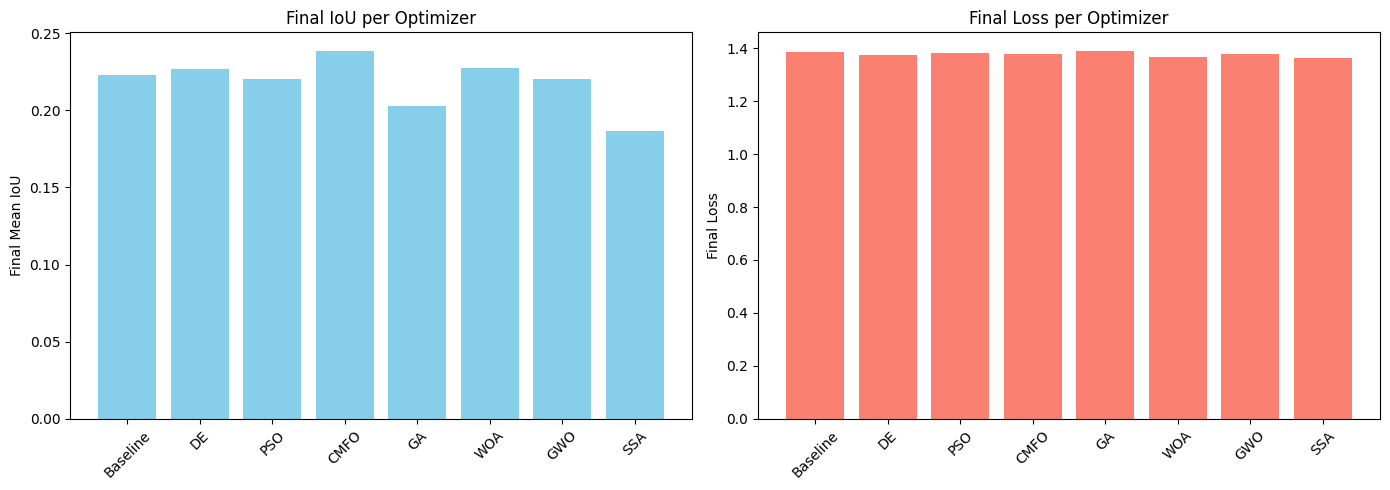

In [ ]:
# Collect final values
names = ["Baseline", "DE", "PSO", "CMFO", "GA", "WOA", "GWO", "SSA"]
final_losses = [
    baseline_history["loss"][-1],
    de_history["loss"][-1],
    pso_history["loss"][-1],
    cmfo_history["loss"][-1],
    ga_history["loss"][-1],
    woa_history["loss"][-1],
    gwo_history["loss"][-1],
    ssa_history["loss"][-1],
]
final_ious = [
    baseline_history["iou"][-1],
    de_history["iou"][-1],
    pso_history["iou"][-1],
    cmfo_history["iou"][-1],
    ga_history["iou"][-1],
    woa_history["iou"][-1],
    gwo_history["iou"][-1],
    ssa_history["iou"][-1],
]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(14, 5))

# Final IoU bar
plt.subplot(1, 2, 1)
plt.bar(x, final_ious, color="skyblue")
plt.xticks(x, names, rotation=45)
plt.ylabel("Final Mean IoU")
plt.title("Final IoU per Optimizer")

# Final loss bar
plt.subplot(1, 2, 2)
plt.bar(x, final_losses, color="salmon")
plt.xticks(x, names, rotation=45)
plt.ylabel("Final Loss")
plt.title("Final Loss per Optimizer")

plt.tight_layout()
plt.show()


/tmp/ipython-input-3496101515.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


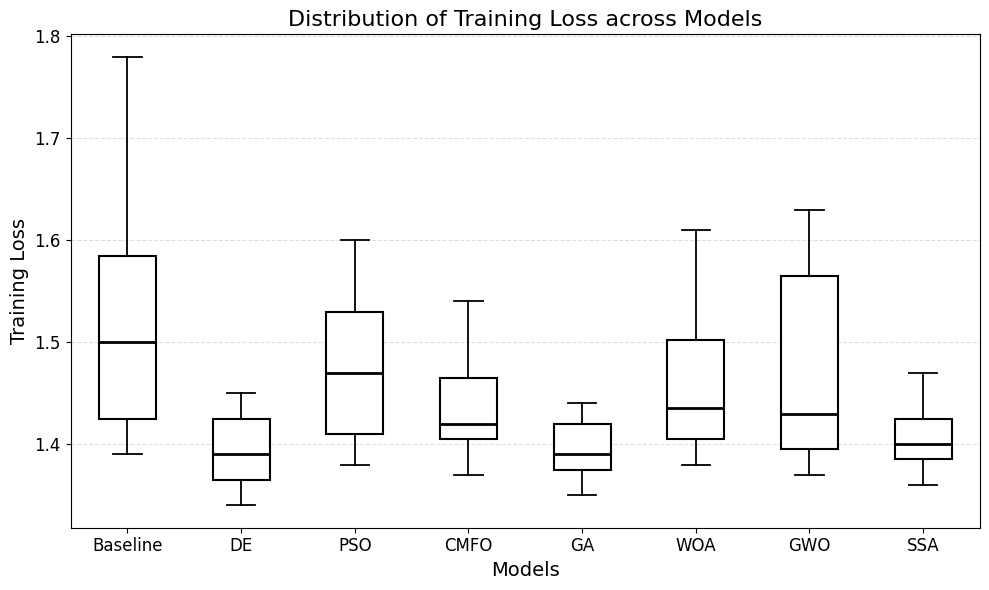

In [ ]:
import matplotlib.pyplot as plt

data = [
    baseline_history["loss"],
    de_history["loss"],
    pso_history["loss"],
    cmfo_history["loss"],
    ga_history["loss"],
    woa_history["loss"],
    gwo_history["loss"],
    ssa_history["loss"]
]

labels = [
    "Baseline",
    "DE",
    "PSO",
    "CMFO",
    "GA",
    "WOA",
    "GWO",
    "SSA"
]

plt.figure(figsize=(10, 6), facecolor="white")

plt.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    boxprops=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=1.5
    ),
    showfliers=False,
    medianprops=dict(
        color="black",
        linewidth=2
    ),
    whiskerprops=dict(
        color="black",
        linewidth=1.3
    ),
    capprops=dict(
        color="black",
        linewidth=1.3
    )
)

plt.xlabel("Models", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.title("Distribution of Training Loss Across Models", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

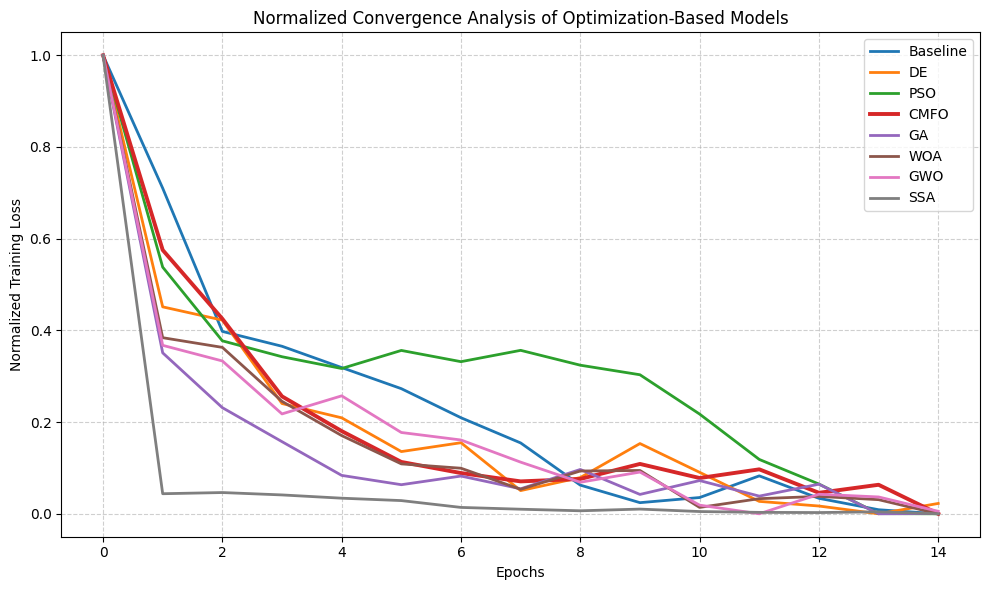

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize(x):
    x = np.array(x)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

plt.figure(figsize=(10, 6))

plt.plot(normalize(baseline_history["loss"]), label="Baseline", linewidth=2)
plt.plot(normalize(de_history["loss"]), label="DE", linewidth=2)
plt.plot(normalize(pso_history["loss"]), label="PSO", linewidth=2)
plt.plot(normalize(cmfo_history["loss"]), label="CMFO", linewidth=2.8)
plt.plot(normalize(ga_history["loss"]), label="GA", linewidth=2)
plt.plot(normalize(woa_history["loss"]), label="WOA", linewidth=2)
plt.plot(normalize(gwo_history["loss"]), label="GWO", linewidth=2)
plt.plot(normalize(ssa_history["loss"]), label="SSA", linewidth=2)

plt.xlabel("Epochs")
plt.ylabel("Normalized Training Loss")
plt.title("Normalized Convergence Analysis of Optimization-Based Models")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


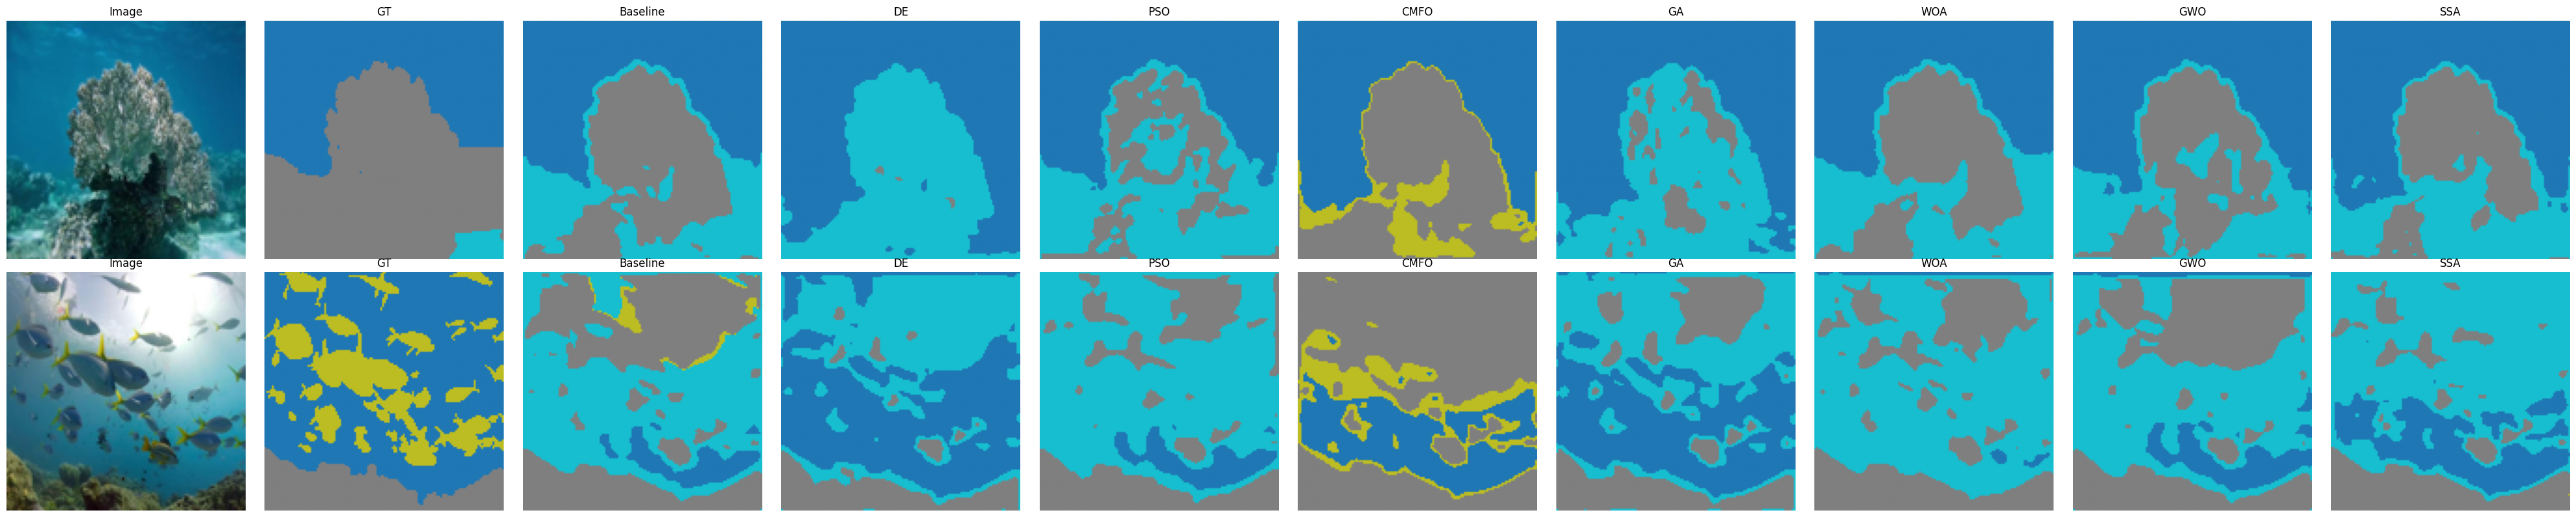

In [ ]:
def show_masks_compare(models, model_names, dataloader, num=2):
    for m in models:
        m.eval()

    n_models = len(models)
    cols = 2 + n_models  # Image + GT + one per model

    fig, axes = plt.subplots(num, cols, figsize=(4*cols, 4*num))
    if num == 1:
        axes = axes[None, :]

    with torch.no_grad():
        for i, (images, masks) in enumerate(dataloader):
            if i >= num:
                break
            images, masks = images.to(device), masks.to(device)
            img = images[0].cpu().permute(1, 2, 0).numpy()
            mask = masks[0].cpu().numpy()

            axes[i, 0].imshow(img)
            axes[i, 0].set_title("Image")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(mask, cmap="tab10", vmin=0, vmax=7)
            axes[i, 1].set_title("GT")
            axes[i, 1].axis("off")

            for j, (model, name) in enumerate(zip(models, model_names)):
                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)
                pred = preds[0].cpu().numpy()
                axes[i, 2 + j].imshow(pred, cmap="tab10", vmin=0, vmax=7)
                axes[i, 2 + j].set_title(name)
                axes[i, 2 + j].axis("off")

    plt.tight_layout()
    plt.show()

models = [model_baseline, model_de, model_pso, model_cmfo,
          model_ga, model_woa, model_gwo, model_ssa]
names  = ["Baseline", "DE", "PSO", "CMFO", "GA", "WOA", "GWO", "SSA"]

show_masks_compare(models, names, train_loader, num=2)


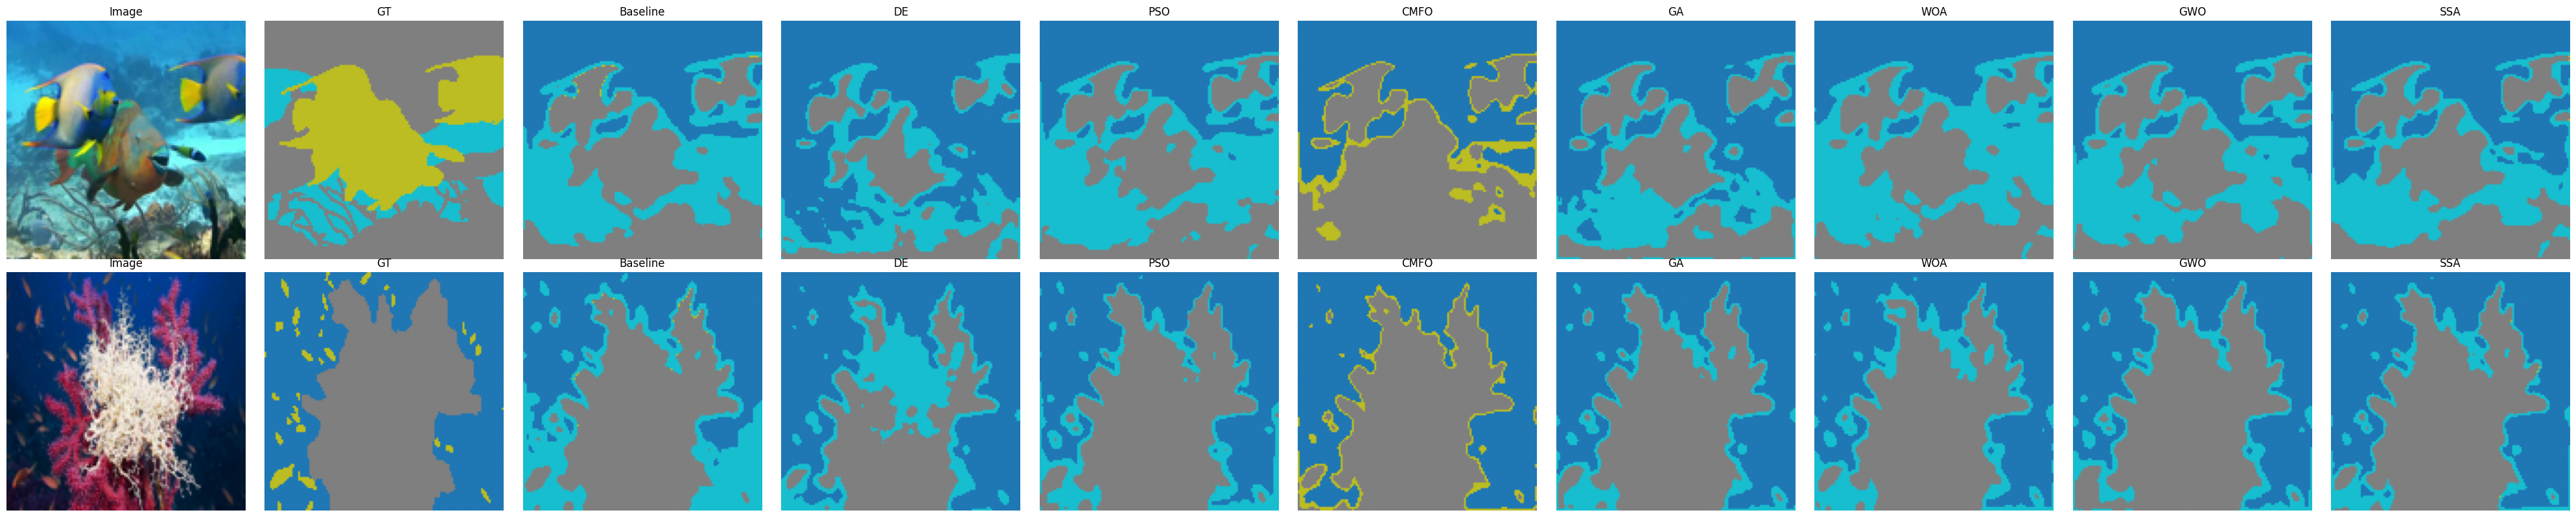

In [ ]:
models = [model_baseline, model_de, model_pso, model_cmfo,
          model_ga, model_woa, model_gwo, model_ssa]
names  = ["Baseline", "DE", "PSO", "CMFO", "GA", "WOA", "GWO", "SSA"]

show_masks_compare(models, names, train_loader, num=2)
